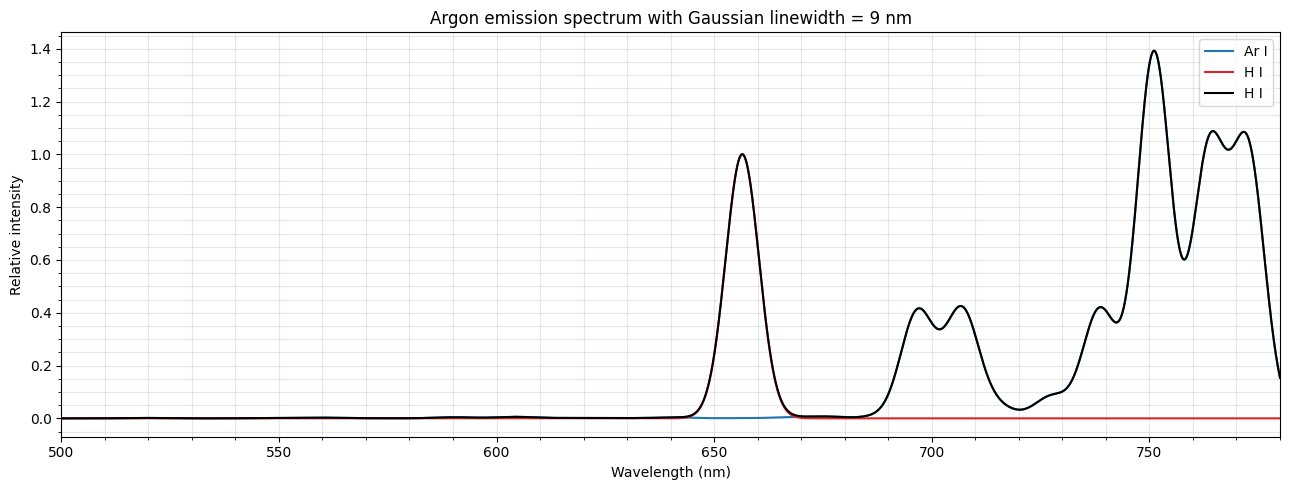

In [24]:
# pip install astroquery astropy numpy matplotlib

import numpy as np
import matplotlib.pyplot as plt
from astroquery.nist import Nist
import astropy.units as u

from nist_utils import ExtractIntensityNist

# ---------------------------------------------------
# Parameters
# ---------------------------------------------------

# Gaussian linewidth (FWHM) in nm
linewidth = 9

# Spectral axis for reconstructed spectrum
lambda_min = 500
lambda_max = 780
Npts = 10000

# Ionization states ,"Si I","H I"
ar_types = ["Ar I","H I"] 

# Colors
colors = ["tab:blue", "tab:red", "tab:green", "tab:orange", "tab:brown"]

# ---------------------------------------------------
# Gaussian conversion
# ---------------------------------------------------

# Convert FWHM -> sigma
sigma = linewidth / (2 * np.sqrt(2 * np.log(2)))

# Wavelength axis
lambda_axis = np.linspace(lambda_min, lambda_max, Npts)

# ---------------------------------------------------
# Figure
# ---------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 5))

spectrumTot = np.zeros_like(lambda_axis)

for ar_type, color in zip(ar_types, colors):

    print(f"Downloading {ar_type} lines...")

    table = Nist.query(
        lambda_min * u.nm,
        lambda_max * u.nm,
        linename=ar_type,
        wavelength_type='vacuum'
    )

    # Wavelength column : get both observed or ritz wavelegnth
    wl_col = "Observed" if "Observed" in table.colnames else "Ritz"

    # Intensity column : only extract those with tabulated rel intensity
    int_col = "Rel." if "Rel." in table.colnames else None

    # Convert wavelengths
    wl = np.array(table[wl_col], dtype=float)
    
    # Remove invalid wavelengths
    mask = np.isfinite(wl)
    wl = wl[mask]
    table = table[mask]

    # Intensities
    if int_col is not None:
        intensity = ExtractIntensityNist(table[int_col])
    else:
        intensity = np.ones_like(wl)

    # Remove invalid intensities
    intensity[~np.isfinite(intensity)] = 1

    # Sort
    idx = np.argsort(wl)
    wl = wl[idx]
    intensity = intensity[idx]

    # normalizing each individual species
    intensity = intensity/max(intensity)
    # ---------------------------------------------------
    # Build Gaussian spectrum
    # ---------------------------------------------------

    spectrum = np.zeros_like(lambda_axis)

    for l, I in zip(wl, intensity):

        gaussian = I * np.exp(
            -(lambda_axis - l)**2 / (2 * sigma**2)
        )

        spectrum += gaussian

    # Plot spectrum
    spectrumTot += spectrum
    ax.plot(
        lambda_axis,
        spectrum,
        color=color,
        linewidth=1.5,
        label=ar_type
    )

    
# ---------------------------------------------------
# Formatting
# ---------------------------------------------------
ax.plot(
    lambda_axis,
    spectrumTot,
    color="black",
    linewidth=1.5,
    label=ar_type
)
    
plt.xlabel("Wavelength (nm)")
plt.ylabel("Relative intensity")
plt.title(f"Argon emission spectrum with Gaussian linewidth = {linewidth} nm")
plt.xlim(lambda_min, lambda_max)
plt.minorticks_on()

plt.grid(True, which='major', alpha=0.6)
plt.grid(True, which='minor', alpha=0.3)

ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()



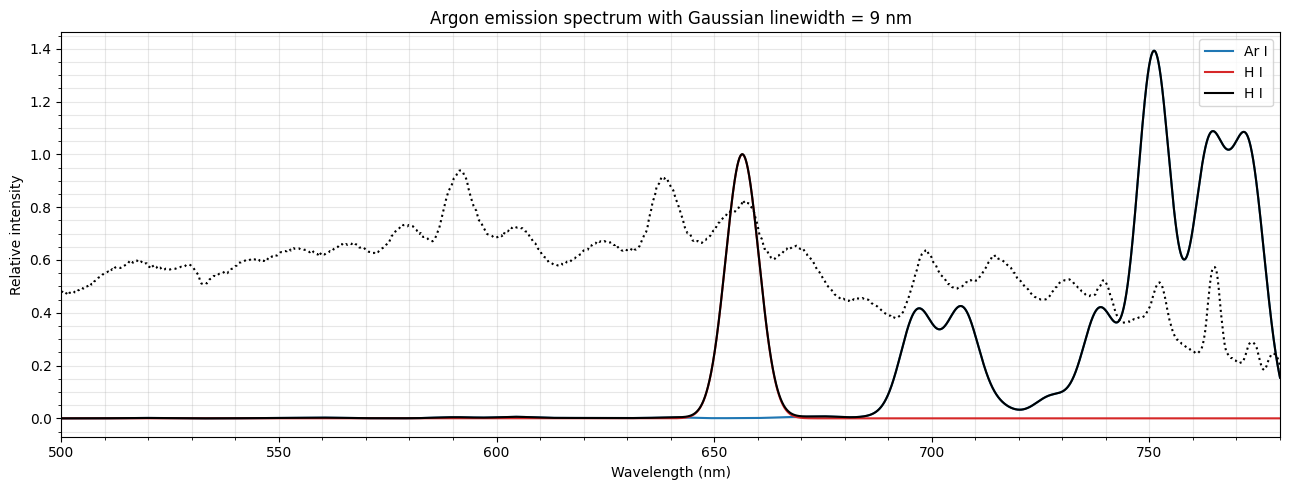

In [25]:
# Full Path to your file
#filename = r"D:\ucla data\spectrum\ArgonLS_63p3dBm_5900torr_500kHzdrive_25msIntTime_ST006871__1__19-46-08-601.txt"
filename = r"D:\ucla data\spectrum\ArgonLS_63p3dBm_5900torr_500kHzdrive_25msIntTime_ST006871__0__19-45-58-918.txt"



# Read file
with open(filename, "r") as f:
    lines = f.readlines()

# Find beginning of spectral data
for i, line in enumerate(lines):
    if "Begin Spectral Data" in line:
        start_index = i + 1
        break

# Read numerical data
data = np.loadtxt(lines[start_index:])

# Separate columns
wavelength = data[:, 0]
intensity = data[:, 1]
ax.plot(wavelength, intensity/max(intensity) , label="new",color='black',linestyle=':')
display(ax.figure)


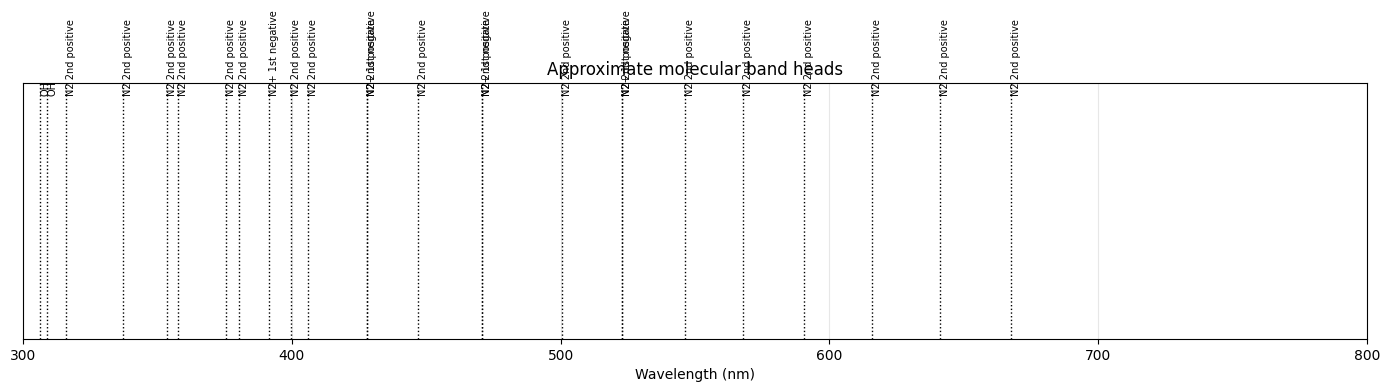

In [11]:
molecular_bands = {
    "OH": [
        306.4, 309.0
    ],

    "N2 2nd positive": [
        315.9,
        337.1,
        353.7,
        357.7,
        375.5,
        380.5,
        399.5,
        405.9,
        427.8,
        447.1,
        470.9,
        500.5,
        522.8,
        546.2,
        568.0,
        590.6,
        615.9,
        641.3,
        667.7
    ],

    "N2+ 1st negative": [
        391.4,
        427.8,
        470.9,
        522.8
    ]
}


fig, ax = plt.subplots(figsize=(14,4))

for label, wavelengths in molecular_bands.items():

    for wl in wavelengths:

        ax.axvline(
            wl,
            color="black",
            linestyle=":",
            linewidth=1
        )

        ax.text(
            wl,
            1.0,
            label,
            rotation=90,
            fontsize=7,
            verticalalignment="bottom"
        )

ax.set_xlim(300,800)
ax.set_ylim(0,1.05)

ax.set_xlabel("Wavelength (nm)")
ax.set_yticks([])

ax.set_title("Approximate molecular band heads")

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

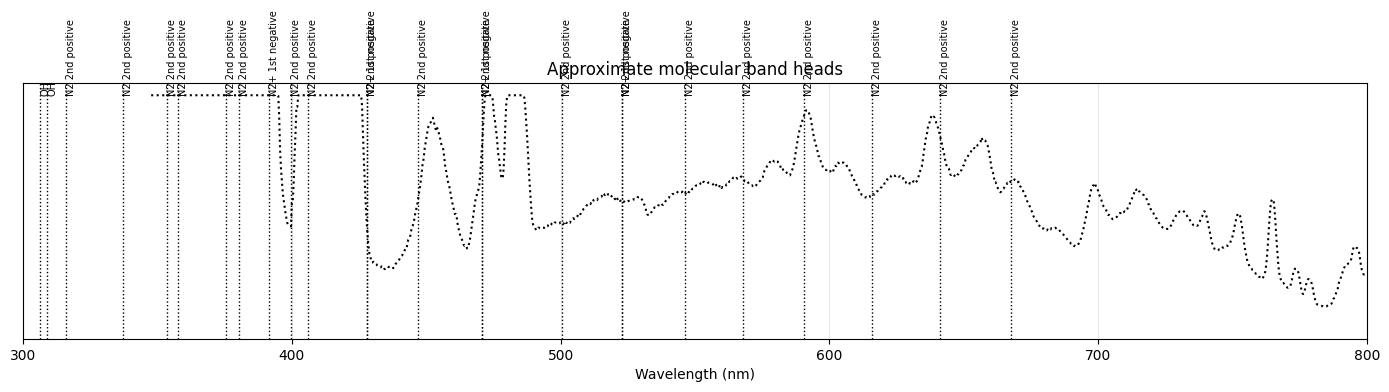

In [12]:
# Full Path to your file
filename = r"D:\ucla data\spectrum\ArgonLS_63p3dBm_5900torr_500kHzdrive_25msIntTime_ST006871__0__19-45-58-918.txt"

# Read file
with open(filename, "r") as f:
    lines = f.readlines()

# Find beginning of spectral data
for i, line in enumerate(lines):
    if "Begin Spectral Data" in line:
        start_index = i + 1
        break

# Read numerical data
data = np.loadtxt(lines[start_index:])

# Separate columns
wavelength = data[:, 0]
intensity = data[:, 1]
ax.plot(wavelength, intensity/max(intensity) , label="new",color='black',linestyle=':')
display(ax.figure)